# 🧠 Neural Network from Scratch (NumPy) — Full Mathematical Explanation

---

## 📌 1. Problem Setup

We solve a binary classification problem:

- Input: $X \in \mathbb{R}^{m \times n}$
- Output: $y \in \{0,1\}^{m \times 1}$
- Goal: Learn a function $f(X) \rightarrow y$

---

## 🏗️ 2. Model Architecture

A 2-layer neural network:

Input → Hidden Layer → Output Layer

### Dimensions

- $X$: $(m, n)$  
- $W_1$: $(n, h)$  
- $b_1$: $(1, h)$  
- $W_2$: $(h, 1)$  
- $b_2$: $(1, 1)$  

---

## 🔢 3. Forward Propagation

### Step 1: Hidden Layer Linear Transformation

$$
Z_1 = X W_1 + b_1
$$

---

### Step 2: Activation (Sigmoid)

$$
A_1 = \sigma(Z_1) = \frac{1}{1 + e^{-Z_1}}
$$

---

### Step 3: Output Layer Linear Transformation

$$
Z_2 = A_1 W_2 + b_2
$$

---

### Step 4: Final Prediction

$$
A_2 = \sigma(Z_2)
$$

👉 $A_2$ represents **predicted probability**

---

## 📉 4. Loss Function (Binary Cross-Entropy)

$$
L = -\frac{1}{m} \sum_{i=1}^{m} \left[
y^{(i)} \log(A_2^{(i)}) +
(1 - y^{(i)}) \log(1 - A_2^{(i)})
\right]
$$

---

## 🔁 5. Backpropagation (Gradient Derivation)

### 🔴 Step 1: Output Layer Gradient

$$
dZ_2 = A_2 - y
$$

---

### 🔴 Step 2: Gradients for Output Weights

$$
dW_2 = \frac{1}{m} A_1^T dZ_2
$$

$$
db_2 = \frac{1}{m} \sum dZ_2
$$

---

### 🔴 Step 3: Backpropagate to Hidden Layer

$$
dA_1 = dZ_2 W_2^T
$$

Sigmoid derivative:

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z))
$$

$$
dZ_1 = dA_1 \cdot A_1 (1 - A_1)
$$

---

### 🔴 Step 4: Gradients for Hidden Weights

$$
dW_1 = \frac{1}{m} X^T dZ_1
$$

$$
db_1 = \frac{1}{m} \sum dZ_1
$$

---

## 🔧 6. Gradient Descent Update

$$
W_1 := W_1 - \alpha dW_1
$$

$$
b_1 := b_1 - \alpha db_1
$$

$$
W_2 := W_2 - \alpha dW_2
$$

$$
b_2 := b_2 - \alpha db_2
$$

Where:

- $\alpha$ = learning rate

---

## 🔁 7. Training Algorithm

For each epoch:

1. Forward pass  
$$
X \rightarrow Z_1 \rightarrow A_1 \rightarrow Z_2 \rightarrow A_2
$$

2. Compute loss  

3. Backpropagation  
$$
A_2 \rightarrow dZ_2 \rightarrow dW_2, db_2 \rightarrow dZ_1 \rightarrow dW_1, db_1
$$

4. Update parameters  

---

## 🎯 8. Prediction Rule

$$
\hat{y} =
\begin{cases}
1 & \text{if } A_2 > 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

---

## 🧩 9. Key Insights

### ✔ Nonlinearity

Without activation:

$$
Z = XW
$$

→ Only linear boundary  

With sigmoid → nonlinear decision boundary  

---

### ✔ Role of Hidden Layer

- Feature transformation  
- Enables complex patterns  

---

### ✔ Efficient Derivative

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z))
$$

---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.lr = learning_rate

        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, a):
        return a * (1 - a)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)

        return self.A2

    def compute_loss(self, y, y_pred):
        eps = 1e-8
        return -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))

    def backward(self, X, y):
        m = X.shape[0]

        dZ2 = self.A2 - y
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.sigmoid_derivative(self.A1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y, epochs=2000):
        losses = []

        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            self.backward(X, y)

            losses.append(loss)

            if epoch % 200 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

        return losses

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

In [3]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
model = NeuralNetwork(input_size=2, hidden_size=8, output_size=1, learning_rate=0.1)

losses = model.train(X_train, y_train, epochs=2000)

Epoch 0, Loss: 0.6932
Epoch 200, Loss: 0.6929
Epoch 400, Loss: 0.6868
Epoch 600, Loss: 0.5963
Epoch 800, Loss: 0.4124
Epoch 1000, Loss: 0.3423
Epoch 1200, Loss: 0.3141
Epoch 1400, Loss: 0.3012
Epoch 1600, Loss: 0.2955
Epoch 1800, Loss: 0.2929


In [5]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8650


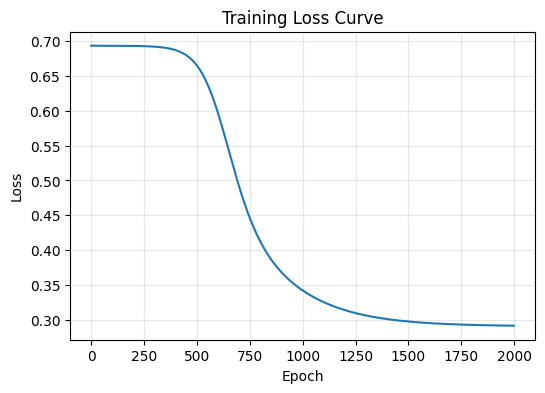

In [6]:
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(alpha=0.3)
plt.show()

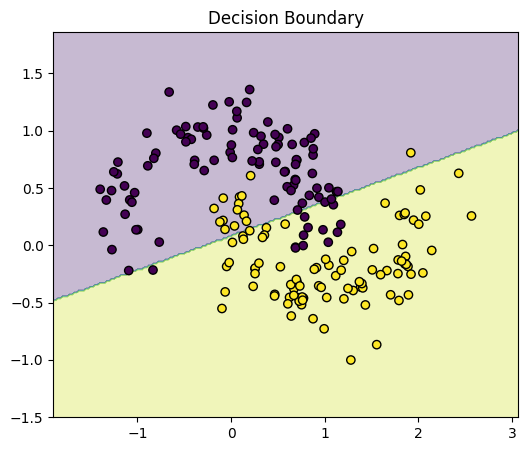

In [7]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y.flatten(), edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(model, X_test, y_test)